In [1]:
import pandas as pd
import seaborn as sns

In [2]:
tips = sns.load_dataset("tips")
titanic = sns.load_dataset("titanic")
flights = sns.load_dataset("flights")
iris = sns.load_dataset("iris")

## BIVARIATE

In [3]:
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
85,34.83,5.17,Female,No,Thur,Lunch,4
83,32.68,5.00,Male,Yes,Thur,Lunch,2
41,17.46,2.54,Male,No,Sun,Dinner,2
212,48.33,9.00,Male,No,Sat,Dinner,4
221,13.42,3.48,Female,Yes,Fri,Lunch,2


<Axes: xlabel='tip', ylabel='total_bill'>

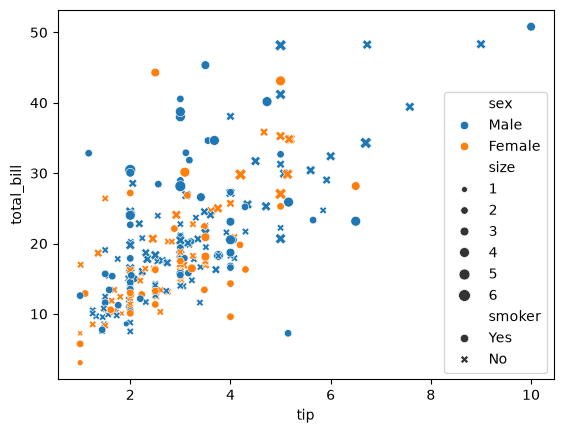

In [13]:
sns.scatterplot(data = tips , x = "tip" , y = "total_bill" , hue = "sex" , style = tips['smoker'], size = "size")

<Axes: xlabel='pclass'>

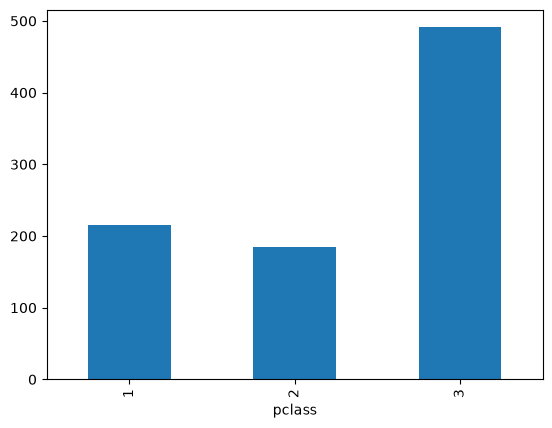

In [19]:
titanic['pclass'].value_counts().sort_index().plot(kind = "bar")

In [21]:
titanic['pclass'] = titanic['pclass'].astype("category")

<Axes: xlabel='pclass', ylabel='fare'>

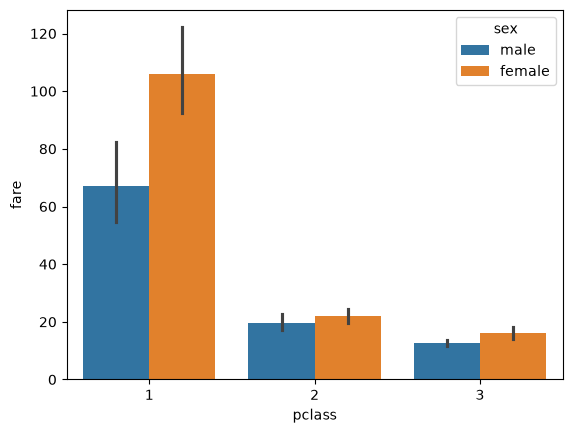

In [25]:
sns.barplot( data =titanic,  x = titanic['pclass'] , y = titanic['fare'], hue = 'sex')

<Axes: xlabel='sex', ylabel='age'>

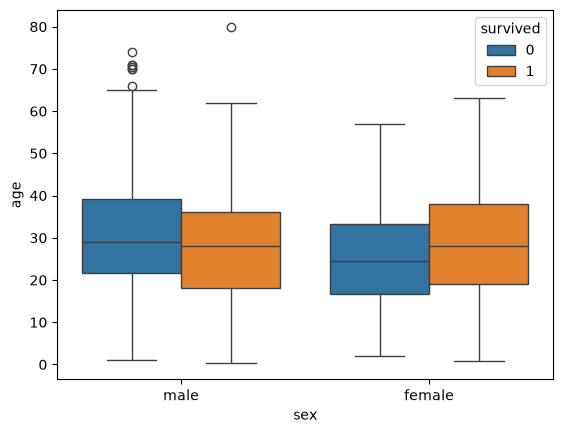

In [28]:
sns.boxplot(data = titanic, x = 'sex' , y = 'age' , hue = 'survived')

<Axes: xlabel='age', ylabel='Density'>

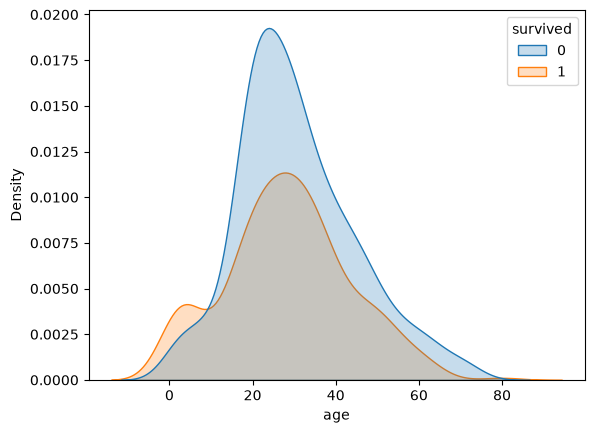

In [33]:
sns.kdeplot(data = titanic , x = 'age' , hue = 'survived' , fill = True)

In [ ]:
# your probability of surviving is more if you are a kid , but your probability of not surviving is more after 15 age or sm

In [37]:
pd.crosstab(titanic['pclass'], titanic['survived'])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


In [39]:
x = titanic.corr(numeric_only = True)

In [40]:
x

,survived,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
age,-0.077221,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


<Axes: >

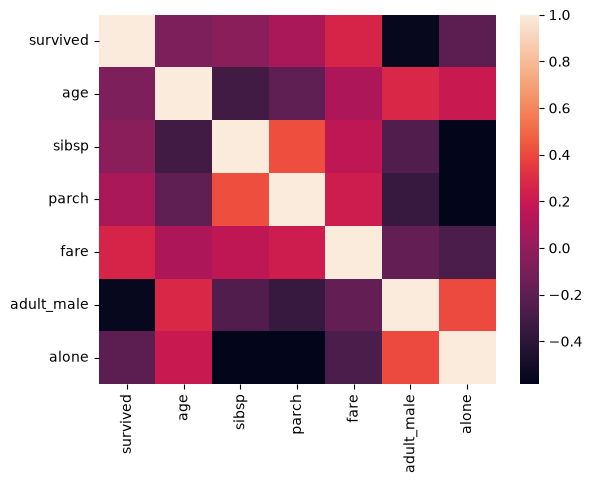

In [41]:
sns.heatmap(x)

<Axes: xlabel='pclass'>

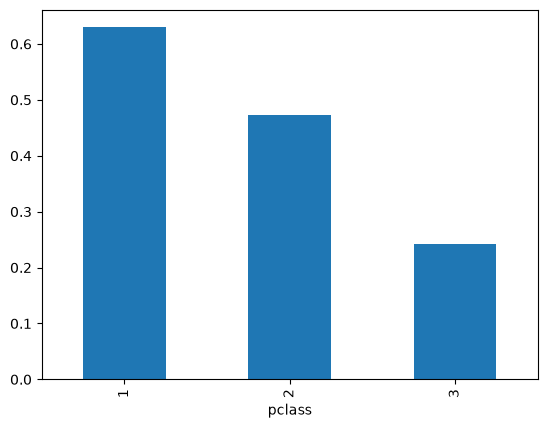

In [48]:
titanic.groupby('pclass')['survived'].mean().plot(kind = "bar")

In [ ]:
# we can see the 1 pclass people survived more than other classes

<Axes: xlabel='sex'>

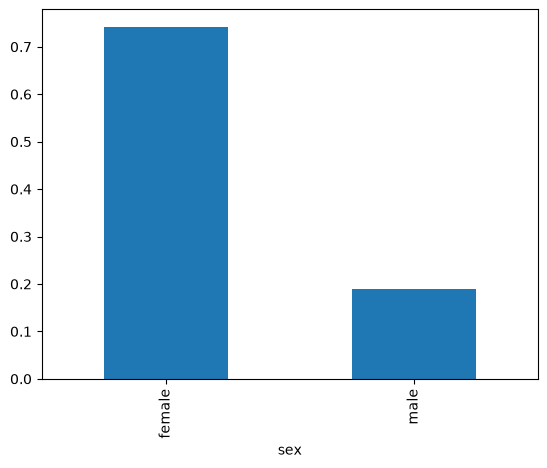

In [49]:
titanic.groupby('sex')['survived'].mean().plot(kind = 'bar')

In [ ]:
#females survived more than males in usual

In [51]:
titanic.groupby('embarked')['survived'].mean()

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64

In [ ]:
# the c embarked people survived more than ususal , could be females or richer people from C

<Figure size 100x50 with 0 Axes>

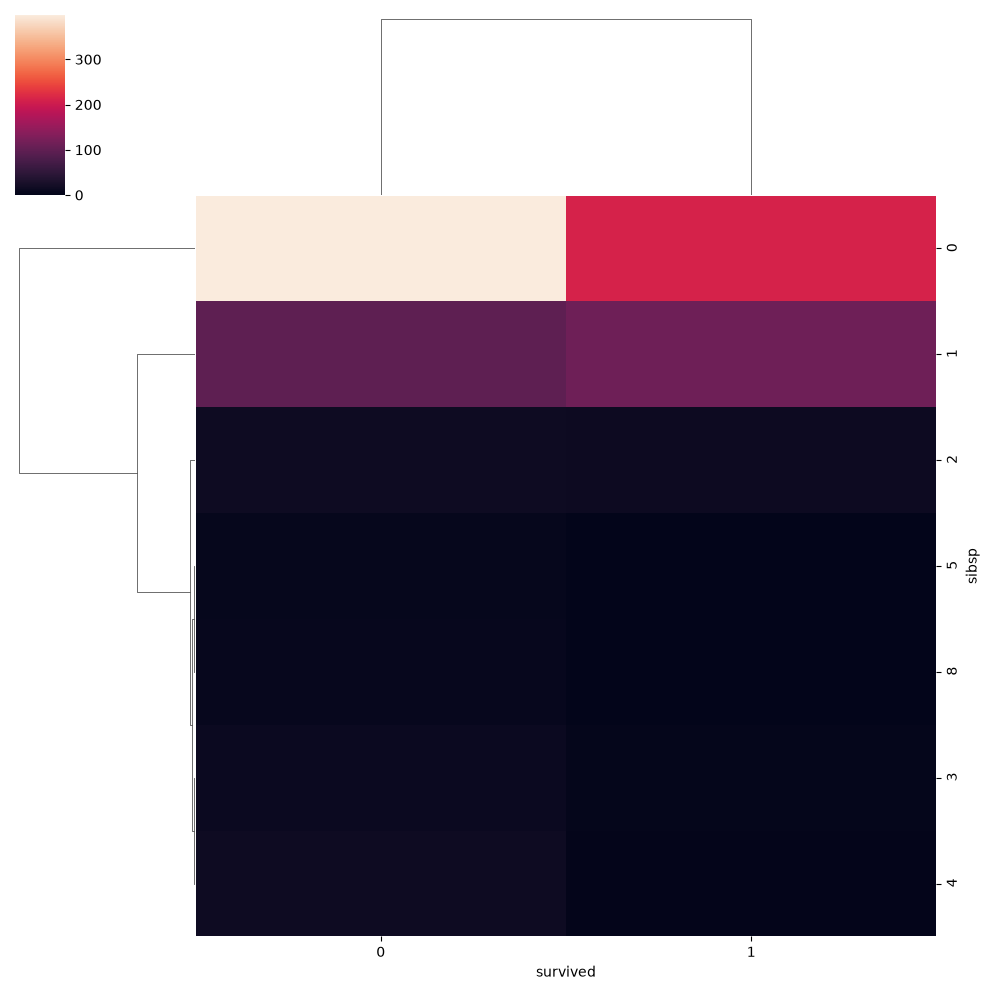

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize = (1,0.5))
sns.clustermap(pd.crosstab(titanic['sibsp'], titanic['survived']))

# PAIRPLOT

In [64]:
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


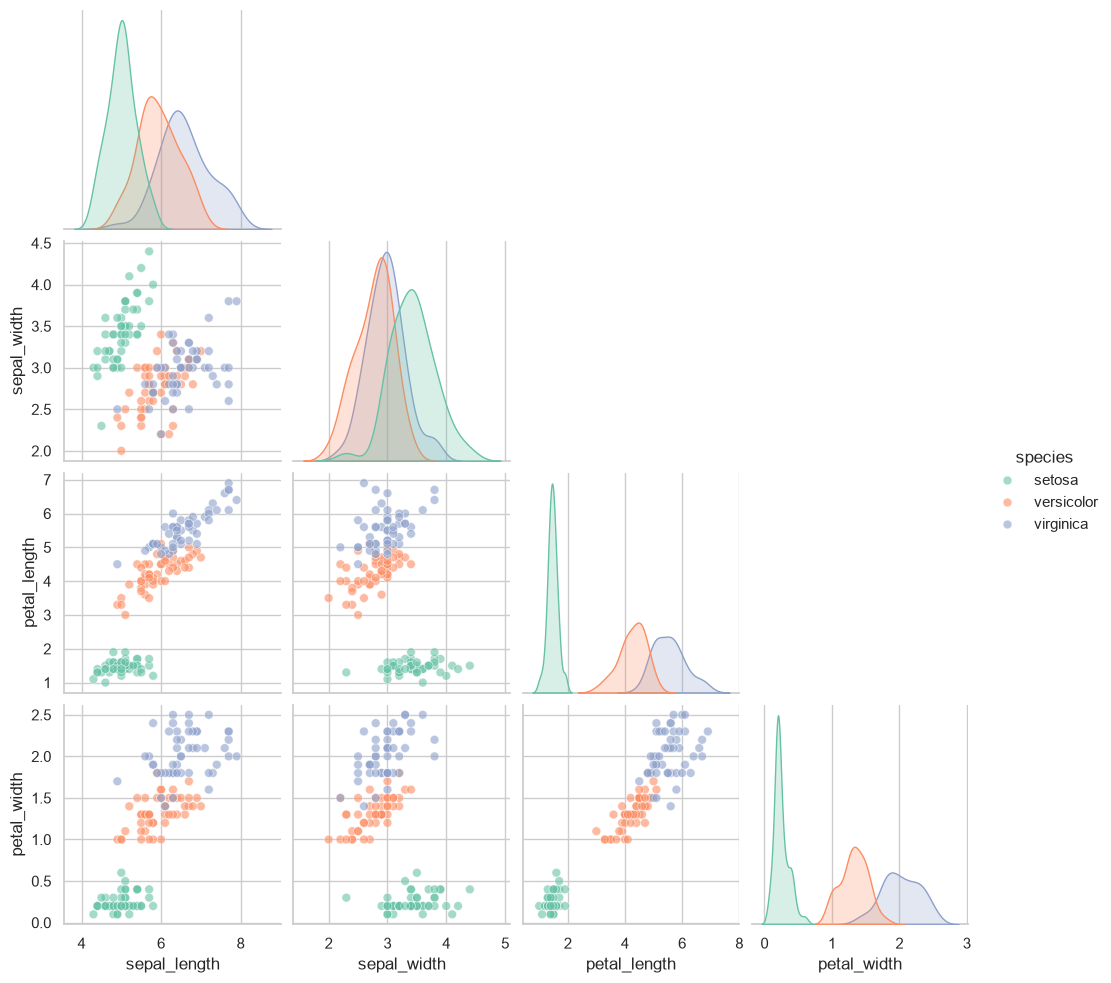

In [74]:
sns.set_theme(style="whitegrid", palette="Set2")

sns.pairplot(
    iris,
    hue="species",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 40},
    height=2.5
)

plt.show()

## LINEPLOT

In [67]:
flights.sample(5)

,year,month,passengers
62,1954,Mar,235
65,1954,Jun,264
90,1956,Jul,413
14,1950,Mar,141
11,1949,Dec,118


In [72]:
flight_df = flights.groupby('year')['passengers'].sum().reset_index()
flight_df

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

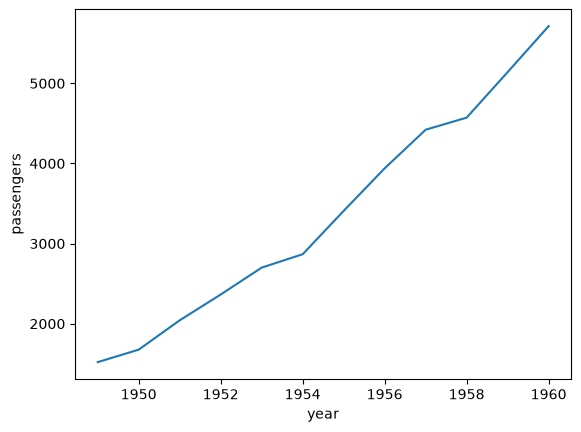

In [73]:
sns.lineplot(data = flight_df , x = "year" , y = "passengers")

In [78]:
x = flights.pivot_table(index = "month", columns = "year" , values = "passengers")
x

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


<Axes: xlabel='year', ylabel='month'>

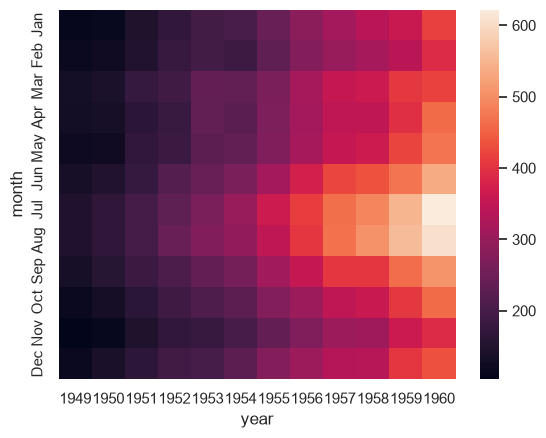

In [79]:
sns.heatmap(x)